# Dataframe of Planetary System Data from INARA

Importing modules

In [16]:
import pandas as pd
import scipy as sp
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error

import astropy.constants as const

Unit conversions

In [17]:
Erg_to_J = 10**-7    # J per erg
cm2_to_m2 = 1/(100**2)  # m2 per cm2
parsec_to_m = 30856775814913673   # m per parsec
SolarRadii_to_m = 6.957*(10**8) # m per solar radii
AU_to_m = 149597870700 # m per AU

Function to generate Pressure-Temperature Profile. Taken from Frontier Development Labs Python code used to create the INARA dataset. The models used in these functions taken from Line et al. (2013)

In [18]:
def xi(gamma, tau):
    return (2.0/3) * (1 + (1/gamma) * (1 + (0.5*gamma*tau-1)*np.exp(-gamma*tau)) +
                        gamma*(1 - 0.5*tau**2) * sp.special.expn(2, gamma*tau)             )    

def PT_line(pressure, params, R_star, T_star, T_int, sma, grav):
    kappa  = 10**(params[0])
    gamma1 = 10**(params[1])
    gamma2 = 10**(params[2])
    alpha, beta = params[3], params[4]

    # Stellar input temperature (at top of atmosphere):
    T_irr = beta * (R_star / (2.0*sma))**0.5 * T_star

    # Gray IR optical depth:
    tau = kappa * (pressure*1e6) / grav # Convert bars to barye (CGS)

    xi1 = xi(gamma1, tau)
    xi2 = xi(gamma2, tau)

    # Temperature profile (Eq. 13 of Line et al. 2013):
    temperature = (0.75 * (T_int**4 * (2.0/3.0 + tau) +
                             T_irr**4 * (1-alpha) * xi1 +
                             T_irr**4 * alpha     * xi2 ) )**0.25

    return temperature

## Ingesting the planetary dataset

In [19]:
df = pd.read_csv('../../../Raw Data/Large Validation Data/Dataset 1/psg_models.csv', index_col = 'PlanetIndex', dtype = {'PlanetIndex': str})

## Calculating Stellar and Planetary Signals for each Planet System

The spectral data provided by the INARA dataset is in (erg/s/cm2) and not per micron. The signals are thus likely the intensity of a given bin of wavelengths. These values thus only need to be summed together and not integrated.

In [20]:
for Planet in df.index:
    FileName = Planet + '.csv'
    Spectral_Data = pd.read_csv('../../../Raw Data/Large Validation Data/Dataset 1/Spectra/' + FileName, usecols = ['wavelength_(um)', 'stellar_signal_(erg/s/cm2)', 'planet_signal_(erg/s/cm2)'])

    Spectral_Data['stellar_signal_(erg/s/cm2)'][0:4378] = Spectral_Data['stellar_signal_(erg/s/cm2)'][0:4378]*(10**10)

    Bolometric_Stellar_Signal = sum(Spectral_Data['stellar_signal_(erg/s/cm2)'].values)
    Bolometric_Stellar_Signal = Bolometric_Stellar_Signal*Erg_to_J*(1/cm2_to_m2)                # Stellar flux as experienced on Earth
    Bolometric_Planet_Signal = sum(Spectral_Data['planet_signal_(erg/s/cm2)'].values)
    Bolometric_Planet_Signal = Bolometric_Planet_Signal*Erg_to_J*(1/cm2_to_m2)                  # Planetary flux as experienced on Earth

    df.loc[Planet, 'Bolometric Stellar Signal (W/m2)'] = Bolometric_Stellar_Signal
    df.loc[Planet, 'Bolometric Planet Signal (W/m2)'] = Bolometric_Planet_Signal 

    SA_Star = 4*(np.pi)*((df.loc[Planet, 'star_radius_in_Solar_radii']*SolarRadii_to_m)**2)     # Surface Area of star
    d = df.loc[Planet, 'distance_from_Earth_to_the_system_in_parsecs']*parsec_to_m + df.loc[Planet, 'semimajor_axis_of_the_planet_in_AU']*AU_to_m + df.loc[Planet, 'planet_radius_in_km']*1000*2    # distance from telescope to surface of star (assuming earth, planet and star are directly in line with one another)
    df.loc[Planet, 'True Stellar Signal (W/m2)'] = (df.loc[Planet, 'Bolometric Stellar Signal (W/m2)']*(4*np.pi*(d**2)))/SA_Star        # Stellar flux released by the surface of the star

    SA_Planet = 4*(np.pi)*((df.loc[Planet, 'planet_radius_in_km']*1000)**2)                     # Surface Area of planet
    d = df.loc[Planet, 'distance_from_Earth_to_the_system_in_parsecs']*parsec_to_m      # distance from earth to planet
    df.loc[Planet, 'True Planet Signal (W/m2)'] = (df.loc[Planet, 'Bolometric Planet Signal (W/m2)']*(4*np.pi*(d**2))) / SA_Planet                  # Planetary flux released by the surface of the planet
                                                  
    # generation of Pressure-Temperature Profiles
    P_prof = np.logspace(np.log10(df.loc[Planet, 'planet_surface_pressure_bars']), np.log10(1e-6), 50) # bar

    density = df.loc[Planet, 'planet_density']
    rplanet     = df.loc[Planet, 'planet_radius_in_km']
    mplanet = density *  (4./3. * np.pi * (rplanet * const.R_earth.cgs.value)**3) / const.M_earth.cgs.value
    surfgrav = const.G.cgs.value * mplanet * const.M_earth.cgs.value /  \
                   (rplanet * const.R_earth.cgs.value)**2
    
    T_prof = PT_line(P_prof, [df.loc[Planet, 'kappa'], df.loc[Planet, 'gamma1'], df.loc[Planet, 'gamma2'], df.loc[Planet, 'alpha'], df.loc[Planet, 'beta']], df.loc[Planet, 'star_radius_in_Solar_radii']* const.R_sun.value, df.loc[Planet, 'star_temperature_in_Kelvin'], 0, df.loc[Planet, 'semimajor_axis_of_the_planet_in_AU']* const.au.value, surfgrav) # K

    df.loc[Planet, 'planet_surface_temperature_Kelvin'] = T_prof[0]
    
    df

C:\Users\Andrew\AppData\Local\Temp\ipykernel_30396\2918750879.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Spectral_Data['stellar_signal_(erg/s/cm2)'][0:4378] = Spectral_Data['stellar_signal_(erg/s/cm2)'][0:4378]*(10**10)
C:\Users\And

## Removing Outliers

In [21]:
# SB_const =  5.670374419*(10**-8)
# df['Planet Flux (SB) (W/m2)'] = SB_const*(df['planet_surface_temperature_Kelvin']**4)
# df = df.loc[df['True Planet Signal (W/m2)'] <= df['Planet Flux (SB) (W/m2)']] # Removing planets that have OLR's greater than their blackbodies

Assumptions:

    No losses of electromagnetic energy from the star/planet to earth.
        Thus the electromangetic radiation experienced per m2 on earth is inversely proportional to 4*pi*d^2

# Batalha 2016 Polynomial Fit for OLR

## Creation of dataframe

In [ ]:
 #  Outgoing Longwave Radiation (W m^-2) from Batalha, 2016 polynomial fit.

df_approx = df[['planet_surface_temperature_Kelvin', 'planet_surface_pressure_bars','True Planet Signal (W/m2)']].copy()

# === column names in Planets.csv ===
T_surf   = "planet_surface_temperature_Kelvin"  # [K]
P_surf   = "planet_surface_pressure_bars"       # [bar]
COL_FH2   = "fH2 frac"



def folr_wm2(T_surf, P_surf, fH2):
    Tk  = np.asarray(T_surf,  dtype=float)
    Ps  = np.asarray(P_surf,  dtype=float)
    fH2 = np.asarray(fH2, dtype=float)

    if np.any(Tk <= 0) or np.any(Ps <= 0):
        raise ValueError("Tk must be >0 K and Ps >0 bar for log10.")

    logt = np.log10(Tk)
    logp = np.log10(Ps)
    one_m_frac = (1.0 - fH2)

    A1 = (
        4.696772785202295e+01 * logt**4
        - 8.522999151672911e+00 * logt**3 * one_m_frac
        - 3.658091802200866e+00 * logt**3 * logp
        - 4.703855594559182e+02 * logt**3
        - 2.162164715676355e+00 * logt**2 * one_m_frac**2
        - 8.943156639285714e-01 * logt**2 * one_m_frac * logp
        + 6.182559313686860e+01 * logt**2 * one_m_frac
        + 2.802840498827926e+00 * logt**2 * logp**2
        + 4.081371718097563e+01 * logt**2 * logp
    )

    A2 = (
        1.769475591457944e+03 * logt**2
        - 4.069326230548901e+00 * logt * one_m_frac**3
        + 4.791164127321047e-01 * logt * one_m_frac**2 * logp
        + 2.013837444139825e+01 * logt * one_m_frac**2
        + 2.610518804147137e-02 * logt * one_m_frac * logp**2
        + 3.540728646617164e+00 * logt * one_m_frac * logp
        - 1.570111078637131e+02 * logt * one_m_frac
        - 3.188377339447028e-01 * logt * logp**3
        - 1.502329193533661e+01 * logt * logp**2
        - 1.341988705085224e+02 * logt * logp
    )

    A3 = (
        -2.957968741415568e+03 * logt
        - 7.755396320218135e-01 * one_m_frac**4
        + 5.869223796106973e-01 * one_m_frac**3 * logp
        + 1.289249534077652e+01 * one_m_frac**3
        - 2.431077344360770e-02 * one_m_frac**2 * logp**2
        - 2.520196555925526e+00 * one_m_frac**2 * logp
        - 4.024463851824954e+01 * one_m_frac**2
        - 1.850549436217017e-02 * one_m_frac * logp**3
        - 5.128247821880338e-02 * one_m_frac * logp**2
        - 2.135703301729639e+00 * one_m_frac * logp
    )

    A4 = (
        1.413752905644611e+02 * one_m_frac
        + 1.951595943948440e-02 * logp**4
        + 8.693519467787629e-01 * logp**3
        + 1.994328685663450e+01 * logp**2
        + 1.368296512344305e+02 * logp
        + 1.855402408416981e+03
    )
    return (1.0 / 1000) * 10 ** (A1 + A2 + A3 + A4)

df_approx['Planet Flux (Polynomial, Batalha 2016) (W/m2)'] = folr_wm2(df_approx[T_surf], df_approx[P_surf ], 0)

## Statistical Analysis of polynomial approximation for Total Outgoing Longwave Radiation from Planets

The two groups are significantly different
p-value: 2.7187093822278378e-182


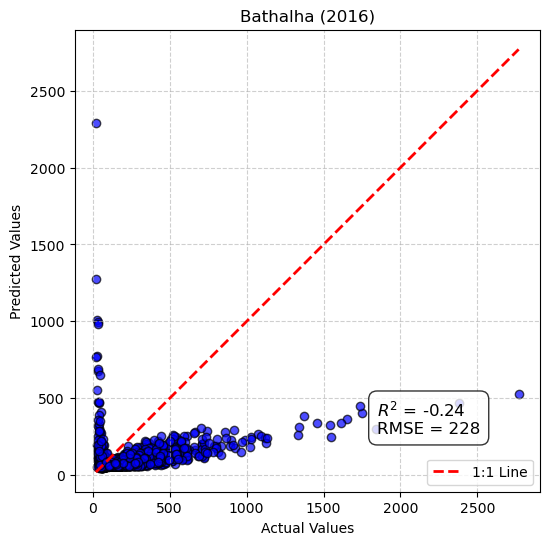

In [23]:
# Testing for Normality
Actual_Planet_Signals = df_approx['True Planet Signal (W/m2)']
Approximation = df_approx["Planet Flux (Polynomial, Batalha 2016) (W/m2)"]

sA, pA = stats.normaltest(Actual_Planet_Signals)
SB, pB = stats.normaltest(Approximation)

if pA > 0.05 and pB > 0.05:
    t, p = stats.ttest_ind(Actual_Planet_Signals, Approximation)
else:
    MW, p = stats.mannwhitneyu(Actual_Planet_Signals, Approximation)

if p < 0.05:
    print('The two groups are significantly different')
else:
    print('The two groups of not significantly different')

print('p-value: ' + str(p))

Rsqr = r2_score(Actual_Planet_Signals, Approximation)
RMSE = np.sqrt(mean_squared_error(Actual_Planet_Signals, Approximation))

# Parity Plot
plt.figure(figsize=(6,6))
plt.scatter(Actual_Planet_Signals, Approximation, color='blue', edgecolor='k', alpha=0.7)

min_val = min(Actual_Planet_Signals.min(), Approximation.min())
max_val = max(Actual_Planet_Signals.max(), Approximation.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Bathalha (2016)')
plt.legend(loc = 'lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')  

textstr = f"$R^2$ = {Rsqr:.3g}\nRMSE = {RMSE:.3g}"
plt.text(
    0.65, 0.2, textstr,
    transform=plt.gca().transAxes,     # position relative to axes
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8)
)


plt.show()

# "Principles of Planetary Climate" RAYMOND T. PIERREHUMBERT 2010

## Data Ingestion and Dataframe Preparation, humidity

In [24]:
# Humidty calculation
df_approx = df[['planet_surface_temperature_Kelvin', 'planet_surface_pressure_bars', 'H2O', 'CO2', 'True Planet Signal (W/m2)']].copy()

T_COL  = "planet_surface_temperature_Kelvin"
P_COL  = "planet_surface_pressure_bars"
H2O_COL = "H2O"
CO2_COL = "CO2"

def _detect_fraction(series, label):
    v = series.astype(float)
    m = np.nanmean(v)
    if m > 1.0:
        print(f"{label}: detected ppmv (mean={m:.2f}) → converting to fraction.")
        return v / 1e6
    else:
        print(f"{label}: detected fraction (mean={m:.6f}) → using as-is.")
        return v

def saturation_vapour_pressure_bar(Tk):    #Buck (1981) saturation vapour pressure (over liquid water). Good around 0–50 °C; acceptable for Earth-like lower troposphere.  
    Tc = np.asarray(Tk) - 273.15  # °C
    e_kPa = 0.61121 * np.exp((18.678 - (Tc / 234.5)) * (Tc / (257.14 + Tc)))
    return e_kPa * 0.01  # kPa → bar

def add_humidity_and_co2_columns(df_in):
    df_out = df_in.copy()

    # Convert H2O, CO2 to mole fractions
    df_out["H2O_frac"] = _detect_fraction(df_out[H2O_COL], "H2O")
    df_out["CO2_frac"] = _detect_fraction(df_out[CO2_COL], "CO2")

    # Partial pressure of water vapour
    Tk     = df_out[T_COL].astype(float).to_numpy()
    Ps_bar = df_out[P_COL].astype(float).to_numpy()
    yH2O   = df_out["H2O_frac"].astype(float).to_numpy()

    p_H2O_bar = yH2O * Ps_bar
    p_sat_bar = saturation_vapour_pressure_bar(Tk)

    with np.errstate(divide="ignore", invalid="ignore"):
        hrel = p_H2O_bar / p_sat_bar
    hrel = np.clip(hrel, 0.0, 1.0)
    hrel[~np.isfinite(hrel)] = np.nan

    df_out["hrel_frac"] = hrel
    df_out["CO2_ppmv"]  = df_out["CO2_frac"] * 1e6

    return df_out

df_approx = add_humidity_and_co2_columns(df_approx)

H2O: detected fraction (mean=0.033206) → using as-is.
CO2: detected fraction (mean=0.299169) → using as-is.


In [25]:
df_approx

,planet_surface_temperature_Kelvin,planet_surface_pressure_bars,H2O,CO2,True Planet Signal (W/m2),H2O_frac,CO2_frac,hrel_frac,CO2_ppmv
PlanetIndex,,,,,,,,,
0002085,231.916921,3.460688,0.062379,0.045443,162.958004,0.062379,0.045443,1.0,45442.904000
0002091,192.484480,0.888166,0.027754,0.284429,87.673532,0.027754,0.284429,1.0,284429.465007
0002094,213.534139,1.145327,0.036288,0.309758,121.185268,0.036288,0.309758,1.0,309757.692873
0002101,258.289280,1.376675,0.068989,0.065438,210.762217,0.068989,0.065438,1.0,65437.523000
0000203,326.042465,4.201480,0.036229,0.105633,405.419282,0.036229,0.105633,1.0,105632.723140
...,...,...,...,...,...,...,...,...,...
0034914,255.505460,2.202056,0.002955,0.524416,147.679378,0.002955,0.524416,1.0,524415.892699
0034947,321.888777,4.034092,0.055016,0.027422,555.932254,0.055016,0.027422,1.0,27421.687000
0034960,212.540509,2.918169,0.014148,0.349605,104.924647,0.014148,0.349605,1.0,349605.423200


In [26]:
CO2_COL_PPMV = "CO2_ppmv"
HREL_COL     = "hrel_frac"

# If hrel missing for any reason, default to 0.5
if HREL_COL not in df_approx.columns:
    df_approx[HREL_COL] = 0.5
if CO2_COL_PPMV not in df_approx.columns:
    # Fall back if user skipped step 1
    df_approx[CO2_COL_PPMV] = _detect_fraction(df["CO2"], "CO2") * 1e6

# Humidity grid (fraction) and corresponding coefficients 
_hgrid = np.array([0.0,   0.1,    0.5,    1.0])
_A = np.array([
    [313.80,  -6.27500,  -0.36107, -0.019467],  # dry
    [277.28,  -5.94160,  -0.35596, -0.020237],  # 0.1
    [259.52,  -5.53320,  -0.33915, -0.018932],  # 0.5
    [249.10,  -5.18300,  -0.32187, -0.017367],  # saturated
], )  # columns: a0, a1, a2, a3

def _interp_coeffs(hrel):
    h = np.clip(np.asarray(hrel), _hgrid[0], _hgrid[-1])
    a0 = np.interp(h, _hgrid, _A[:,0])
    a1 = np.interp(h, _hgrid, _A[:,1])
    a2 = np.interp(h, _hgrid, _A[:,2])
    a3 = np.interp(h, _hgrid, _A[:,3])
    return a0, a1, a2, a3

def olr_humidity_poly(co2_ppmv, hrel):
    co2 = np.asarray(co2_ppmv)
    a0, a1, a2, a3 = _interp_coeffs(hrel)
    valid = co2 > 0
    x = np.full_like(co2, np.nan)
    x[valid] = np.log(co2[valid] / 100.0)
    return a0 + a1*x + a2*(x**2) + a3*(x**3)

df_approx["Planet Flux (Polynomial, RT Pierre, 2010"] = olr_humidity_poly(
    df_approx[CO2_COL_PPMV].to_numpy(),
    df_approx[HREL_COL].to_numpy())

df_approx["Planet Flux (Polynomial, RT Pierre, 2010"] = df_approx["Planet Flux (Polynomial, RT Pierre, 2010"]

## Statistical Analysis of Raymond T. Pierrehumbert approximation

The two groups are significantly different
p-value: 1.2361940434209095e-29


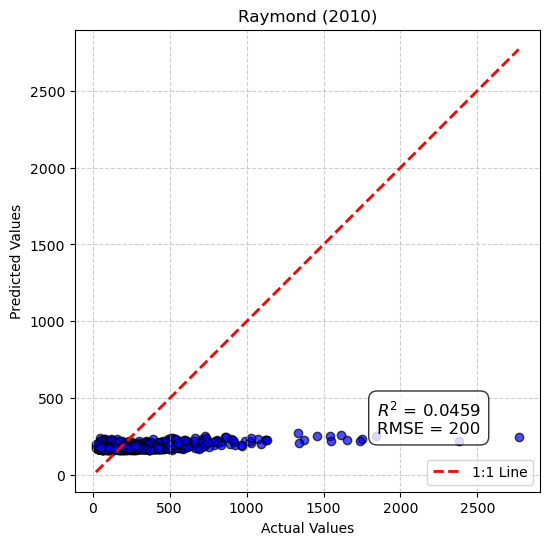

In [27]:
Actual_Planet_Signals = df_approx['True Planet Signal (W/m2)']
Approximation = df_approx["Planet Flux (Polynomial, RT Pierre, 2010"]

sA, pA = stats.normaltest(Actual_Planet_Signals)
SB, pB = stats.normaltest(Approximation)

if pA > 0.05 and pB > 0.05:
    t, p = stats.ttest_ind(Actual_Planet_Signals, Approximation)
else:
    MW, p = stats.mannwhitneyu(Actual_Planet_Signals, Approximation)

if p < 0.05:
    print('The two groups are significantly different')
else:
    print('The two groups of not significantly different')

print('p-value: ' + str(p))


Rsqr = r2_score(Actual_Planet_Signals, Approximation)
RMSE = np.sqrt(mean_squared_error(Actual_Planet_Signals, Approximation))

# Parity Plot
plt.figure(figsize=(6,6))
plt.scatter(Actual_Planet_Signals, Approximation, color='blue', edgecolor='k', alpha=0.7)

min_val = min(Actual_Planet_Signals.min(), Approximation.min())
max_val = max(Actual_Planet_Signals.max(), Approximation.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Raymond (2010)')
plt.legend(loc = 'lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')  

textstr = f"$R^2$ = {Rsqr:.3g}\nRMSE = {RMSE:.3g}"

plt.text(
    0.65, 0.2, textstr,
    transform=plt.gca().transAxes,     # position relative to axes
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8)
)


plt.show()

# "Habitable Planets with High Obliquities" Williams and Kasting 1997

## Data Ingestion and Dataframe Preparation

In [28]:
df_approx = df[['planet_surface_temperature_Kelvin', 'True Planet Signal (W/m2)']].copy()
df_approx['pCO2 (bar)'] = df['planet_surface_pressure_bars']*df['CO2']

df_approx['Planet Flux (Polynomial, Wiiliams and Kasting 1997) (W/m2)'] = (
    9.468980
    - 7.714727e-5 * np.log((df_approx['pCO2 (bar)'] / 3.3) * (10**-4))
    - 2.794778 * df_approx['planet_surface_temperature_Kelvin']
    - 3.244753e-3 * np.log((df_approx['pCO2 (bar)'] / 3.3) * (10**-4)) * df_approx['planet_surface_temperature_Kelvin']
    - 3.547406e-4 * (np.log((df_approx['pCO2 (bar)'] / 3.3) * (10**-4)))**2
    + 2.212108e-2 * df_approx['planet_surface_temperature_Kelvin']**2
    + 2.229142e-3 * (np.log((df_approx['pCO2 (bar)'] / 3.3) * (10**-4)))**2 * df_approx['planet_surface_temperature_Kelvin']
    + 3.088497e-5 * np.log((df_approx['pCO2 (bar)'] / 3.3) * (10**-4)) * df_approx['planet_surface_temperature_Kelvin']**2
    - 2.789815e-5 * (np.log((df_approx['pCO2 (bar)'] / 3.3) * (10**-4)))**2 * df_approx['planet_surface_temperature_Kelvin']**2
    - 3.442973e-3 * (np.log((df_approx['pCO2 (bar)'] / 3.3) * (10**-4)))**3
    - 3.361939e-5 * df_approx['planet_surface_temperature_Kelvin']**3
    + 9.173169e-3 * (np.log((df_approx['pCO2 (bar)'] / 3.3) * (10**-4)))**3 * df_approx['planet_surface_temperature_Kelvin']
    - 7.775195e-5 * (np.log((df_approx['pCO2 (bar)'] / 3.3) * (10**-4)))**3 * df_approx['planet_surface_temperature_Kelvin']**2
    - 1.679112e-7 * np.log((df_approx['pCO2 (bar)'] / 3.3) * (10**-4)) * df_approx['planet_surface_temperature_Kelvin']**3
    + 6.590999e-8 * (np.log((df_approx['pCO2 (bar)'] / 3.3) * (10**-4)))**2 * df_approx['planet_surface_temperature_Kelvin']**3
    + 1.528125e-7 * (np.log((df_approx['pCO2 (bar)'] / 3.3) * (10**-4)))**3 * df_approx['planet_surface_temperature_Kelvin']**3
    - 3.367567e-2 * (np.log((df_approx['pCO2 (bar)'] / 3.3) * (10**-4)))**4
    - 1.631909e-4 * (np.log((df_approx['pCO2 (bar)'] / 3.3) * (10**-4)))**4 * df_approx['planet_surface_temperature_Kelvin']
    + 3.663871e-6 * (np.log((df_approx['pCO2 (bar)'] / 3.3) * (10**-4)))**4 * df_approx['planet_surface_temperature_Kelvin']**2
    - 9.255646e-9 * (np.log((df_approx['pCO2 (bar)'] / 3.3) * (10**-4)))**4 * df_approx['planet_surface_temperature_Kelvin']**3
)

## Statistical Analysis of Williams and Kastings polynomial approximation for OLR

The two groups are significantly different
p-value: 4.499479795160618e-65


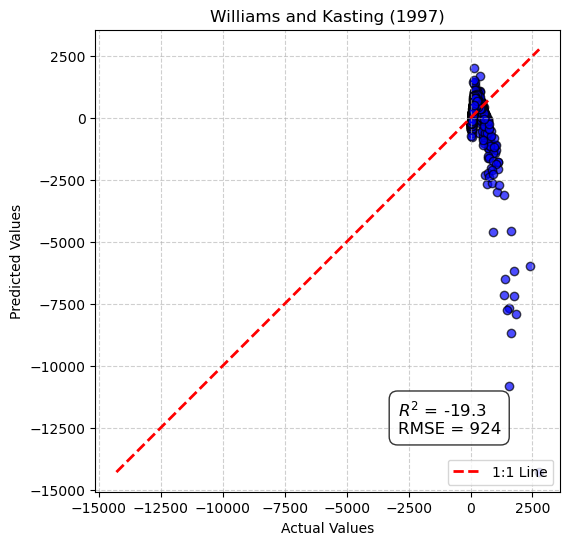

In [29]:
Actual_Planet_Signals = df_approx['True Planet Signal (W/m2)']
Approximation = df_approx['Planet Flux (Polynomial, Wiiliams and Kasting 1997) (W/m2)']

sA, pA = stats.normaltest(Actual_Planet_Signals)
SB, pB = stats.normaltest(Approximation)

if pA > 0.05 and pB > 0.05:
    t, p = stats.ttest_ind(Actual_Planet_Signals, Approximation)
else:
    MW, p = stats.mannwhitneyu(Actual_Planet_Signals, Approximation)

if p < 0.05:
    print('The two groups are significantly different')
else:
    print('The two groups of not significantly different')

print('p-value: ' + str(p))


Rsqr = r2_score(Actual_Planet_Signals, Approximation)
RMSE = np.sqrt(mean_squared_error(Actual_Planet_Signals, Approximation))

# Parity Plot
plt.figure(figsize=(6,6))
plt.scatter(Actual_Planet_Signals, Approximation, color='blue', edgecolor='k', alpha=0.7)

min_val = min(Actual_Planet_Signals.min(), Approximation.min())
max_val = max(Actual_Planet_Signals.max(), Approximation.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Williams and Kasting (1997)')
plt.legend(loc = 'lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')  

textstr = f"$R^2$ = {Rsqr:.3g}\nRMSE = {RMSE:.3g}"

plt.text(
    0.65, 0.2, textstr,
    transform=plt.gca().transAxes,     # position relative to axes
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8)
)


plt.show()

The model overpredicts the OLR. If the effects of the other greenhouse gasses were to be included (by means of CO2 equivalence), perhaps the model accuracy would increase.